# Cross-Validation: Fold-Wise Post-Training with the Notebook Phase Pipeline

This notebook reproduces the `final_results.ipynb` CV reporting/plotting flow, but each fold is trained using the same staged post-training process used in `Pretrained_VAE_EndtoEnd_attempt_2.ipynb` (Stage A warmup with frozen base, Stage B adaptive full unfreeze).


## 1. Import Necessary Modules and Libraries


In [1]:
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.model_selection import KFold, train_test_split

try:
    from IPython.display import display
except Exception:
    def display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)

try:
    from skmultilearn.model_selection import IterativeStratification, iterative_train_test_split
except ModuleNotFoundError as exc:
    raise ImportError(
        "scikit-multilearn is required for the multilabel iterative stratified evaluation in this notebook. "
        "Install it with `python -m pip install scikit-multilearn` or sync the project environment."
    ) from exc

## 2. Configuration and Phase-Pipeline Settings


In [2]:
# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, 'set_float32_matmul_precision'):
    torch.set_float32_matmul_precision('high')

# --- Core training settings (aligned with Pretrained_VAE_EndtoEnd_attempt_2.ipynb) ---
BATCH_SIZE = 128
MAX_LEN = 120
PHASE1_EPOCHS = 90
WARMUP_EPOCHS = 15
PHASE2_EPOCHS = 80
MIN_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 12
KL_ANNEAL_EPOCHS = 10
LR_SCHEDULER_FACTOR = 0.25
LR_SCHEDULER_PATIENCE = 4

PHASE1_LR = 5e-4
WARMUP_LR = 1e-4
PHASE2_LR = 5e-5
HEAD_LR = 5e-5
BASE_LR = 1e-7
WEIGHT_DECAY = 1e-2
PHASE2_PRED_WEIGHT = 1.0
PHASE2_RECON_WEIGHT = 0.0

DROPOUT = 0.1
LATENT_DIM = 292

RUN_SMOKE = False
SMOKE_FOLDS = 2
SMOKE_EPOCHS = 2
RUN_FULL = True
FORCE_CPU = False
SAVE_EPOCH_CHECKPOINTS = False

# --- Data and checkpoint paths ---
DATA_ROOT = Path('data')
TRAIN_CSV = DATA_ROOT / 'Train' / 'tox21_train_clean.csv'
VAL_CSV = DATA_ROOT / 'Val' / 'tox21_val_clean.csv'
TEST_CSV = DATA_ROOT / 'Test' / 'tox21_test_clean.csv'

# Start each fold from the Phase-1 checkpoint (avoid leakage from Phase-2 checkpoint)
CHECKPOINT_PATH = Path('artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase1_best.pt')
CV_CHECKPOINT_DIR = Path('reports/cv_fold_checkpoints')
CV_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

for path in [TRAIN_CSV, VAL_CSV, TEST_CSV, CHECKPOINT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')

# --- Fold strategies ---
N_FOLDS = 5
STRATEGY_ORDER = ['random', 'multilabel_iterstrat']
STRATEGY_LABELS = {
    'random': 'Random 5-Fold CV',
    'multilabel_iterstrat': 'Multilabel Iterative Stratified 5-Fold CV',
}
GLOBAL_METRICS = ['macro_auroc', 'macro_auprc', 'micro_auroc', 'micro_auprc']
PER_TASK_METRICS = ['AUROC', 'AUPRC', 'Accuracy', 'F1', 'Precision', 'Recall']

FIXED_POSTTRAIN_PARAMS = {
    'phase1_checkpoint_path': str(CHECKPOINT_PATH),
    'posttraining_pipeline': 'stage_a_head_warmup_then_stage_b_full_unfreeze',
    'warmup_epochs': WARMUP_EPOCHS,
    'phase2_epochs': PHASE2_EPOCHS,
    'warmup_lr': WARMUP_LR,
    'head_lr': HEAD_LR,
    'base_lr': BASE_LR,
    'weight_decay': WEIGHT_DECAY,
    'phase2_pred_weight': PHASE2_PRED_WEIGHT,
    'phase2_recon_weight': PHASE2_RECON_WEIGHT,
    'kl_anneal_epochs': KL_ANNEAL_EPOCHS,
    'min_epochs': MIN_EPOCHS,
    'patience': EARLY_STOPPING_PATIENCE,
    'training_in_notebook': True,
}

TOX21_TASKS = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase',
    'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma',
    'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
]

device = torch.device('cpu') if FORCE_CPU else torch.device(
    'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
)

print('Device:', device)
print('Torch version:', torch.__version__)
print('SELFIES version:', sf.__version__)
print('RUN_FULL:', RUN_FULL, '| RUN_SMOKE:', RUN_SMOKE)
print('Fold-wise phase-training recipe:')
print(FIXED_POSTTRAIN_PARAMS)


Device: mps
Torch version: 2.10.0
SELFIES version: 2.1.1
RUN_FULL: True | RUN_SMOKE: False
Fold-wise phase-training recipe:
{'phase1_checkpoint_path': 'artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase1_best.pt', 'posttraining_pipeline': 'stage_a_head_warmup_then_stage_b_full_unfreeze', 'warmup_epochs': 15, 'phase2_epochs': 80, 'warmup_lr': 0.0001, 'head_lr': 5e-05, 'base_lr': 1e-07, 'weight_decay': 0.01, 'phase2_pred_weight': 1.0, 'phase2_recon_weight': 0.0, 'kl_anneal_epochs': 10, 'min_epochs': 50, 'patience': 12, 'training_in_notebook': True}


## 3. Load Tox21 Data and Build the Sequence Dataset Using Phase-1 Tokenization


In [3]:
ckpt = torch.load(CHECKPOINT_PATH, map_location='cpu')
print('checkpoint keys:', sorted(ckpt.keys()))

TOKEN_TO_IDX = ckpt['token_to_idx']
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}
PAD_IDX = ckpt['pad_idx']
UNK_IDX = ckpt['unk_idx']
EOS_IDX = ckpt['eos_idx']
MAX_LEN = int(ckpt['max_len'])
SEQ_LEN = int(ckpt['seq_len'])
VOCAB_SIZE = int(ckpt['vocab_size'])
LATENT_DIM = int(ckpt['model_state_dict']['fc_mu.weight'].shape[0])
NUM_TASKS = int(ckpt['model_state_dict']['pred_head.9.bias'].shape[0])

if NUM_TASKS != len(TOX21_TASKS):
    raise ValueError(f'Checkpoint head expects {NUM_TASKS} tasks, but TOX21_TASKS has {len(TOX21_TASKS)} entries.')

print(f'SEQ_LEN={SEQ_LEN}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, LATENT_DIM={LATENT_DIM}, NUM_TASKS={NUM_TASKS}')


def load_tox21_frame(path: Path, origin_split: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if 'canonical_smiles' not in df.columns:
        raise ValueError(f'{path} does not contain canonical_smiles')

    missing_tasks = [task for task in TOX21_TASKS if task not in df.columns]
    if missing_tasks:
        raise ValueError(f'{path} missing tasks: {missing_tasks}')

    df = df.dropna(subset=['canonical_smiles']).reset_index(drop=True).copy()
    df['canonical_smiles'] = df['canonical_smiles'].astype(str)
    df[TOX21_TASKS] = df[TOX21_TASKS].apply(pd.to_numeric, errors='coerce')
    df['origin_split'] = origin_split
    return df


def encode_selfies(sf_str: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in sf.split_selfies(sf_str)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def build_aligned_dataset(df: pd.DataFrame, dataset_name: str) -> dict:
    ids_rows = []
    y_rows = []
    mask_rows = []
    meta_rows = []
    dropped_encoding = 0
    dropped_length = 0
    dropped_missing = 0

    for _, row in df.iterrows():
        smiles = row['canonical_smiles']

        try:
            sf_str = sf.encoder(smiles)
        except Exception:
            dropped_encoding += 1
            continue

        tokens = list(sf.split_selfies(sf_str))
        if len(tokens) > MAX_LEN:
            dropped_length += 1
            continue

        labels = row[TOX21_TASKS].to_numpy(dtype=np.float32)
        mask = ~np.isnan(labels)
        if mask.sum() == 0:
            dropped_missing += 1
            continue

        ids = encode_selfies(sf_str)
        labels = np.nan_to_num(labels, nan=0.0)

        ids_rows.append(ids)
        y_rows.append(labels)
        mask_rows.append(mask.astype(np.float32))
        meta_rows.append(
            {
                'canonical_smiles': smiles,
                'selfies': sf_str,
                'origin_split': row['origin_split'],
            }
        )

    if not ids_rows:
        raise RuntimeError('No aligned samples left after SELFIES encoding and checkpoint-length filtering.')

    x = np.full((len(ids_rows), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, ids in enumerate(ids_rows):
        x[i, :len(ids)] = ids

    y = np.array(y_rows, dtype=np.float32)
    mask = np.array(mask_rows, dtype=np.float32)
    meta = pd.DataFrame(meta_rows).reset_index(drop=True)
    meta['aligned_idx'] = np.arange(len(meta))

    return {
        'name': dataset_name,
        'x': x,
        'y': y,
        'mask': mask,
        'meta': meta,
        'stats': {
            'input_rows': int(len(df)),
            'kept_rows': int(len(y)),
            'dropped_encoding': int(dropped_encoding),
            'dropped_length': int(dropped_length),
            'dropped_missing': int(dropped_missing),
        },
    }


train_df_raw = load_tox21_frame(TRAIN_CSV, 'train')
val_df_raw = load_tox21_frame(VAL_CSV, 'val')
test_df_raw = load_tox21_frame(TEST_CSV, 'test')
all_df_raw = pd.concat([train_df_raw, val_df_raw, test_df_raw], ignore_index=True)

sequence_dataset = build_aligned_dataset(all_df_raw, dataset_name='tox21_sequence_ready')

origin_counts = sequence_dataset['meta']['origin_split'].value_counts().to_dict()
orig_train_n = int(origin_counts.get('train', 0))
orig_val_n = int(origin_counts.get('val', 0))
orig_test_n = int(origin_counts.get('test', 0))

if min(orig_train_n, orig_val_n, orig_test_n) <= 0:
    raise ValueError('Expected non-empty train/val/test origins after alignment filtering.')

INNER_VAL_FRACTION = orig_val_n / max(orig_train_n + orig_val_n, 1)

print('Sequence-ready dataset stats:')
print(sequence_dataset['stats'])
print(f"Aligned sequence tensor shape: {sequence_dataset['x'].shape}")
print(f"Aligned label matrix shape   : {sequence_dataset['y'].shape}")
print(f'Inner validation fraction used for fold diagnostics: {INNER_VAL_FRACTION:.4f}')

origin_summary_df = (
    sequence_dataset['meta']['origin_split']
    .value_counts()
    .rename_axis('origin_split')
    .reset_index(name='n_sequence_ready')
)

positive_rate_df = (
    pd.DataFrame(sequence_dataset['y'], columns=TOX21_TASKS)
    .mean()
    .to_frame('positive_rate')
    .T
)

display(origin_summary_df)
display(positive_rate_df)

checkpoint keys: ['best_epoch', 'best_val_token_acc', 'best_val_total', 'decoder_output', 'encoder_layout', 'eos_idx', 'epoch', 'epochs_no_improve', 'history', 'loss_name', 'max_len', 'model_state_dict', 'optimizer_state_dict', 'pad_idx', 'scheduler_state_dict', 'selection_metric', 'seq_len', 'test_metrics', 'token_to_idx', 'unk_idx', 'vocab_size']
SEQ_LEN=121, VOCAB_SIZE=198, MAX_LEN=120, LATENT_DIM=292, NUM_TASKS=12
Sequence-ready dataset stats:
{'input_rows': 7823, 'kept_rows': 7772, 'dropped_encoding': 0, 'dropped_length': 51, 'dropped_missing': 0}
Aligned sequence tensor shape: (7772, 121)
Aligned label matrix shape   : (7772, 12)
Inner validation fraction used for fold diagnostics: 0.1099


,origin_split,n_sequence_ready
0,train,6237
1,val,770
2,test,765


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
positive_rate,0.039115,0.030494,0.098688,0.038085,0.100875,0.044261,0.023546,0.120818,0.033582,0.047864,0.116701,0.052625


## 4. Cross-Validation Split Utilities and Reporting Helpers

In [4]:
def slice_dataset(dataset: dict, indices: np.ndarray, split_name: str) -> dict:
    indices = np.asarray(indices, dtype=np.int64)
    indices = np.sort(indices)
    return {
        'name': split_name,
        'x': dataset['x'][indices],
        'y': dataset['y'][indices],
        'mask': dataset['mask'][indices],
        'meta': dataset['meta'].iloc[indices].reset_index(drop=True),
    }


def _safe_mean(values) -> float:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.mean()) if len(vals) else np.nan


def _safe_std(values) -> float:
    vals = np.asarray(values, dtype=float)
    vals = vals[np.isfinite(vals)]
    return float(vals.std(ddof=1)) if len(vals) > 1 else np.nan


def _mean_task_positive_rate(y: np.ndarray, mask: np.ndarray) -> float:
    rates = []
    for j in range(y.shape[1]):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue
        rates.append(float(y[valid, j].mean()))
    return float(np.mean(rates)) if rates else np.nan


def _any_positive_rate(y: np.ndarray, mask: np.ndarray) -> float:
    valid = mask == 1
    if len(valid) == 0:
        return np.nan
    return float(((y == 1) & valid).any(axis=1).mean())


def _masked_arrays(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray):
    valid = mask.astype(bool)
    return y_true[valid].astype(int), y_probs[valid]


def _macro_auroc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    vals = []
    for j in range(y_true.shape[1]):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue
        yt = y_true[valid, j].astype(int)
        pt = y_probs[valid, j]
        if np.unique(yt).size < 2:
            continue
        vals.append(roc_auc_score(yt, pt))
    return float(np.mean(vals)) if vals else np.nan


def _macro_auprc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    vals = []
    for j in range(y_true.shape[1]):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue
        yt = y_true[valid, j].astype(int)
        pt = y_probs[valid, j]
        if np.unique(yt).size < 2:
            continue
        vals.append(average_precision_score(yt, pt))
    return float(np.mean(vals)) if vals else np.nan


def _micro_auroc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    yt, pt = _masked_arrays(y_true, y_probs, mask)
    if len(yt) == 0 or np.unique(yt).size < 2:
        return np.nan
    return float(roc_auc_score(yt, pt))


def _micro_auprc(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> float:
    yt, pt = _masked_arrays(y_true, y_probs, mask)
    if len(yt) == 0 or np.unique(yt).size < 2:
        return np.nan
    return float(average_precision_score(yt, pt))


def compute_global_metrics(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray) -> dict:
    return {
        'macro_auroc': _macro_auroc(y_true, y_probs, mask),
        'macro_auprc': _macro_auprc(y_true, y_probs, mask),
        'micro_auroc': _micro_auroc(y_true, y_probs, mask),
        'micro_auprc': _micro_auprc(y_true, y_probs, mask),
    }


def _binary_metrics(y_true: np.ndarray, probs: np.ndarray, mask: np.ndarray, threshold: float = 0.5) -> dict:
    valid = mask.astype(bool)
    y_true = y_true[valid].astype(int)
    probs = probs[valid]

    out = {
        'n': int(len(y_true)),
        'Accuracy': np.nan,
        'F1': np.nan,
        'Precision': np.nan,
        'Recall': np.nan,
        'AUROC': np.nan,
        'AUPRC': np.nan,
    }

    if len(y_true) == 0:
        return out

    y_hat = (probs >= threshold).astype(int)
    out['Accuracy'] = float(accuracy_score(y_true, y_hat))
    out['F1'] = float(f1_score(y_true, y_hat, zero_division=0))
    out['Precision'] = float(precision_score(y_true, y_hat, zero_division=0))
    out['Recall'] = float(recall_score(y_true, y_hat, zero_division=0))

    if np.unique(y_true).size >= 2:
        out['AUROC'] = float(roc_auc_score(y_true, probs))
        out['AUPRC'] = float(average_precision_score(y_true, probs))

    return out


def build_global_report_df(fold_summary_df: pd.DataFrame, pooled_summary: dict) -> pd.DataFrame:
    rows = []
    for metric in GLOBAL_METRICS:
        rows.append(
            {
                'metric': metric,
                'cv_mean': _safe_mean(fold_summary_df[metric]),
                'cv_std': _safe_std(fold_summary_df[metric]),
                'pooled_oof': pooled_summary[metric],
            }
        )
    return pd.DataFrame(rows)


def build_task_summary_df(task_fold_df: pd.DataFrame, y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray, tasks: list[str]) -> pd.DataFrame:
    rows = []
    for j, task in enumerate(tasks):
        sub = task_fold_df[task_fold_df['task'] == task].copy()
        oof_res = _binary_metrics(y_true[:, j], y_probs[:, j], mask[:, j], threshold=0.5)
        valid = mask[:, j] == 1

        row = {
            'task': task,
            'n_total': int(valid.sum()),
            'positive_rate': float(y_true[valid, j].mean()) if valid.sum() else np.nan,
            'OOF_AUROC': oof_res['AUROC'],
            'OOF_AUPRC': oof_res['AUPRC'],
        }

        for metric in PER_TASK_METRICS:
            row[f'{metric}_mean'] = _safe_mean(sub[metric])
            row[f'{metric}_std'] = _safe_std(sub[metric])

        rows.append(row)

    return pd.DataFrame(rows).sort_values('OOF_AUROC', ascending=False).reset_index(drop=True)


def build_curve_payload(y_true: np.ndarray, y_probs: np.ndarray, mask: np.ndarray, tasks: list[str]):
    roc_curves = {}
    pr_curves = {}
    agg_true = {}
    agg_probs = {}

    for j, task in enumerate(tasks):
        valid = mask[:, j] == 1
        if valid.sum() == 0:
            continue

        yt = y_true[valid, j].astype(int)
        pt = y_probs[valid, j]
        task_res = _binary_metrics(y_true[:, j], y_probs[:, j], mask[:, j], threshold=0.5)

        if np.unique(yt).size >= 2:
            fpr, tpr, _ = roc_curve(yt, pt)
            prec, rec, _ = precision_recall_curve(yt, pt)
            roc_curves[task] = (fpr, tpr, float(task_res['AUROC']))
            pr_curves[task] = (rec, prec, float(task_res['AUPRC']), float(yt.mean()))
            agg_true[task] = yt
            agg_probs[task] = pt

    return roc_curves, pr_curves, agg_true, agg_probs


def make_cv_splits(y: np.ndarray, mask: np.ndarray, strategy: str, n_splits: int = 5, seed: int = 42):
    labels = ((y == 1) & (mask == 1)).astype(np.int64)

    if strategy == 'random':
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return list(splitter.split(np.arange(len(y))))

    if strategy == 'multilabel_iterstrat':
        perm = np.random.default_rng(seed).permutation(len(y))
        y_perm = labels[perm]
        dummy = np.zeros((len(y_perm), 1), dtype=np.int64)
        splitter = IterativeStratification(n_splits=n_splits, order=1)
        splits = []
        for train_rel, val_rel in splitter.split(dummy, y_perm):
            splits.append((perm[train_rel], perm[val_rel]))
        return splits

    raise ValueError(f'Unknown strategy: {strategy}')


def make_inner_validation_split(train_idx: np.ndarray, y: np.ndarray, mask: np.ndarray, strategy: str, val_fraction: float, seed: int):
    train_idx = np.asarray(train_idx, dtype=np.int64)
    if not (0.0 < val_fraction < 1.0):
        raise ValueError(f'val_fraction must be between 0 and 1. Got {val_fraction}.')

    if strategy == 'random':
        inner_train_idx, inner_val_idx = train_test_split(
            train_idx,
            test_size=val_fraction,
            random_state=seed,
            shuffle=True,
        )
        return np.sort(inner_train_idx), np.sort(inner_val_idx)

    if strategy == 'multilabel_iterstrat':
        labels = ((y[train_idx] == 1) & (mask[train_idx] == 1)).astype(np.int64)
        perm = np.random.default_rng(seed).permutation(len(train_idx))
        idx_perm = train_idx[perm].reshape(-1, 1).astype(np.int64)
        labels_perm = labels[perm]
        x_train, _, x_val, _ = iterative_train_test_split(idx_perm, labels_perm, test_size=val_fraction)
        inner_train_idx = x_train.reshape(-1).astype(np.int64)
        inner_val_idx = x_val.reshape(-1).astype(np.int64)
        return np.sort(inner_train_idx), np.sort(inner_val_idx)

    raise ValueError(f'Unknown strategy: {strategy}')

## 5. Model Rebuild and Fold-Wise Phase-2 Training Logic


In [5]:
class Tox21Dataset(Dataset):
    def __init__(self, x, y, mask):
        self.x = torch.as_tensor(x).long()
        self.y = torch.as_tensor(y).float()
        self.mask = torch.as_tensor(mask).float()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.mask[idx]


class VAEWithPredictor(nn.Module):
    def __init__(self, vocab_size, seq_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        self.conv_1 = nn.Conv1d(vocab_size, 9, kernel_size=9)
        self.conv_2 = nn.Conv1d(9, 9, kernel_size=9)
        self.conv_3 = nn.Conv1d(9, 10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            self.flat_features = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(self.flat_features, 435)
        self.fc_mu = nn.Linear(435, LATENT_DIM)
        self.fc_logvar = nn.Linear(435, LATENT_DIM)

        self.decoder_input = nn.Linear(LATENT_DIM, 292)
        self.gru = nn.GRU(input_size=292, hidden_size=501, num_layers=3, batch_first=True)
        self.output = nn.Linear(501, vocab_size)

        self.pred_head = nn.Sequential(
            nn.Linear(LATENT_DIM, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_TASKS),
        )

    def encode(self, x):
        x_onehot = F.one_hot(x, num_classes=self.vocab_size).float().transpose(1, 2).contiguous()
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        return self.fc_mu(x), self.fc_logvar(x)

    def reparam(self, mu, logvar):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mu

    def decode(self, z):
        z = F.selu(self.decoder_input(z))
        x = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(x)
        return self.output(out)

    def predict_logits(self, x):
        mu, logvar = self.encode(x)
        pred_logits = self.pred_head(mu)
        return pred_logits, mu, logvar

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        recon_logits = self.decode(z)
        pred_logits = self.pred_head(mu)
        return recon_logits, mu, logvar, pred_logits


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_base_model() -> VAEWithPredictor:
    model = VAEWithPredictor(VOCAB_SIZE, SEQ_LEN)
    model.load_state_dict(ckpt['model_state_dict'], strict=True)
    return model.to(device)


def freeze_to_head_only(model: nn.Module):
    for name, param in model.named_parameters():
        param.requires_grad = 'pred_head' in name


def unfreeze_all(model: nn.Module):
    for param in model.parameters():
        param.requires_grad = True


def trainable_parameter_count(model: nn.Module) -> int:
    return sum(int(p.numel()) for p in model.parameters() if p.requires_grad)


def make_loader(x, y, mask, batch_size, shuffle):
    return DataLoader(Tox21Dataset(x, y, mask), batch_size=batch_size, shuffle=shuffle)


def kl_beta(epoch):
    return min(1.0, epoch / KL_ANNEAL_EPOCHS)


def compute_loss(
    logits,
    x,
    mu,
    logvar,
    pred,
    y,
    mask,
    beta,
    recon_weight=1.0,
    pred_weight=1.0,
    pos_weight=None,
):
    recon = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        x.view(-1),
        ignore_index=PAD_IDX,
        reduction='sum',
    )

    kl_elementwise = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    kl = kl_elementwise.sum()

    if y is not None and mask.sum() > 0 and pred_weight > 0:
        bce_all = F.binary_cross_entropy_with_logits(
            pred, y, reduction='none', pos_weight=pos_weight
        )
        bce = (bce_all * mask).sum()
    else:
        bce = torch.tensor(0.0, device=logits.device)

    batch_size = x.size(0)
    total_unnormalized = (recon_weight * recon) + (beta * kl) + (pred_weight * bce)
    total = total_unnormalized / batch_size

    return total, recon, kl, bce


def run_epoch(
    model,
    loader,
    optimizer=None,
    epoch=1,
    pretrain_mode=True,
    pos_weight=None,
    phase2_recon_weight=PHASE2_RECON_WEIGHT,
    phase2_pred_weight=PHASE2_PRED_WEIGHT,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    metrics = {'total': 0, 'recon': 0, 'kl': 0, 'bce': 0, 'acc': 0}
    total_tokens = 0
    beta = kl_beta(epoch)

    if pretrain_mode:
        recon_w, pred_w = 1.0, 0.0
    else:
        recon_w, pred_w = phase2_recon_weight, phase2_pred_weight

    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        if is_train:
            optimizer.zero_grad()

        logits, mu, logvar, pred = model(x)
        loss, recon_loss, kl_loss, bce_loss = compute_loss(
            logits,
            x,
            mu,
            logvar,
            pred,
            y,
            mask,
            beta,
            recon_weight=recon_w,
            pred_weight=pred_w,
            pos_weight=pos_weight,
        )

        if is_train:
            loss.backward()
            optimizer.step()

        metrics['total'] += loss.item()
        metrics['recon'] += recon_loss.item()
        metrics['kl'] += kl_loss.item()
        metrics['bce'] += bce_loss.item()

        preds = logits.argmax(dim=-1)
        m = x != PAD_IDX
        metrics['acc'] += ((preds == x) & m).sum().item()
        total_tokens += m.sum().item()

    num_batches = len(loader)
    num_samples = len(loader.dataset)

    return {
        'total': metrics['total'] / num_batches,
        'recon_raw': metrics['recon'] / num_samples,
        'recon_per_token': metrics['recon'] / total_tokens,
        'kl_raw': metrics['kl'] / num_samples,
        'bce_raw': metrics['bce'] / num_samples,
        'token_acc': metrics['acc'] / total_tokens,
    }


def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
):
    return {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer is not None else None,
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'epoch': int(epoch),
        'best_epoch': int(best_epoch) if best_epoch is not None else None,
        'best_val_total': float(best_val_total) if best_val_total is not None else None,
        'best_val_token_acc': float(best_val_token_acc) if best_val_token_acc is not None else None,
        'epochs_no_improve': int(epochs_no_improve),
        'token_to_idx': TOKEN_TO_IDX,
        'seq_len': SEQ_LEN,
        'vocab_size': VOCAB_SIZE,
        'max_len': MAX_LEN,
        'pad_idx': PAD_IDX,
        'unk_idx': UNK_IDX,
        'eos_idx': EOS_IDX,
        'history': history,
        'encoder_layout': 'onehot_channels_first_seqconv',
        'decoder_output': 'logits',
        'loss_name': 'token_cross_entropy_plus_kl',
        'selection_metric': 'val_token_acc',
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    best_val_token_acc: float | None,
    epochs_no_improve: int,
    optimizer=None,
    scheduler=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        best_val_token_acc=best_val_token_acc,
        epochs_no_improve=epochs_no_improve,
        optimizer=optimizer,
        scheduler=scheduler,
    )

    save_dir.mkdir(parents=True, exist_ok=True)
    last_path = save_dir / f'{checkpoint_stem}_last.pt'
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f'{checkpoint_stem}_epoch_{epoch:03d}.pt'
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f'{checkpoint_stem}_best.pt'
        torch.save(payload, best_path)


def load_checkpoint(path, model, optimizer=None, scheduler=None):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer and checkpoint['optimizer_state_dict']:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    return checkpoint.get('history', None), checkpoint.get('epoch', 0)


def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    y_train: np.ndarray,
    mask_train: np.ndarray,
    y_val: np.ndarray,
    mask_val: np.ndarray,
    *,
    model: nn.Module,
    optimizer,
    scheduler=None,
    history: dict | None = None,
    start_epoch: int = 0,
    min_epochs: int = MIN_EPOCHS,
    max_epochs: int = PHASE2_EPOCHS,
    early_stopping_patience: int = EARLY_STOPPING_PATIENCE,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    best_epoch: int | None = None,
    best_val_token_acc: float | None = None,
    best_val_total: float | None = None,
    epochs_no_improve: int = 0,
    pretrain_mode: bool = False,
    scheduler_mode: str = 'min',
    pos_weight: torch.Tensor | None = None,
    phase2_recon_weight: float = PHASE2_RECON_WEIGHT,
    phase2_pred_weight: float = PHASE2_PRED_WEIGHT,
):
    if scheduler is None:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode=scheduler_mode,
            factor=LR_SCHEDULER_FACTOR,
            patience=LR_SCHEDULER_PATIENCE,
            min_lr=1e-6,
        )

    train_loader = make_loader(train_x, y_train, mask_train, BATCH_SIZE, True)
    val_loader = make_loader(val_x, y_val, mask_val, BATCH_SIZE, False)

    metrics_to_track = [
        'beta', 'lr', 'train_total', 'val_total',
        'train_recon_per_token', 'val_recon_per_token',
        'train_recon_raw', 'val_recon_raw',
        'train_kl', 'val_kl', 'train_token_acc', 'val_token_acc',
        'train_bce', 'val_bce',
    ]

    if history is None:
        history = {m: [] for m in metrics_to_track}
    else:
        for key in metrics_to_track:
            history.setdefault(key, [])

    if scheduler_mode == 'max':
        if best_val_token_acc is None:
            best_val_token_acc = (
                float(np.max(history['val_token_acc']))
                if history['val_token_acc']
                else float('-inf')
            )
        best_val_total = (
            float(np.min(history['val_total']))
            if history['val_total']
            else float('inf')
        )
    else:
        if best_val_total is None:
            best_val_total = (
                float(np.min(history['val_total']))
                if history['val_total']
                else float('inf')
            )
        best_val_token_acc = (
            float(np.max(history['val_token_acc']))
            if history['val_token_acc']
            else float('-inf')
        )

    early_stopped = False
    last_epoch = start_epoch

    for ep in range(start_epoch + 1, max_epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            epoch=ep,
            pretrain_mode=pretrain_mode,
            pos_weight=pos_weight,
            phase2_recon_weight=phase2_recon_weight,
            phase2_pred_weight=phase2_pred_weight,
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            optimizer=None,
            epoch=ep,
            pretrain_mode=pretrain_mode,
            pos_weight=pos_weight,
            phase2_recon_weight=phase2_recon_weight,
            phase2_pred_weight=phase2_pred_weight,
        )

        if scheduler_mode == 'max':
            scheduler.step(val_metrics['token_acc'])
        else:
            scheduler.step(val_metrics['total'])

        current_lr = float(optimizer.param_groups[0]['lr'])

        history['beta'].append(kl_beta(ep))
        history['lr'].append(current_lr)
        history['train_total'].append(train_metrics['total'])
        history['val_total'].append(val_metrics['total'])
        history['train_bce'].append(train_metrics['bce_raw'])
        history['val_bce'].append(val_metrics['bce_raw'])
        history['train_token_acc'].append(train_metrics['token_acc'])
        history['val_token_acc'].append(val_metrics['token_acc'])
        history['train_recon_per_token'].append(train_metrics['recon_per_token'])
        history['val_recon_per_token'].append(val_metrics['recon_per_token'])
        history['train_recon_raw'].append(train_metrics['recon_raw'])
        history['val_recon_raw'].append(val_metrics['recon_raw'])
        history['train_kl'].append(train_metrics['kl_raw'])
        history['val_kl'].append(val_metrics['kl_raw'])

        if scheduler_mode == 'max':
            is_best = val_metrics['token_acc'] > (best_val_token_acc + 1e-12)
        else:
            is_best = val_metrics['total'] < (best_val_total - 1e-12)

        if is_best:
            best_val_token_acc = float(val_metrics['token_acc'])
            best_val_total = float(val_metrics['total'])
            best_epoch = ep
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"\n[Epoch {ep:03d}] Diagnostic (Raw Magnitudes)")
        print(
            f"  TRAIN | Recon: {train_metrics['recon_raw']:10.2f} | "
            f"BCE: {train_metrics['bce_raw']:.4f} | KL: {train_metrics['kl_raw']:.4f}"
        )
        print(
            f"  VAL   | Recon: {val_metrics['recon_raw']:10.2f} | "
            f"BCE: {val_metrics['bce_raw']:.4f} | KL: {val_metrics['kl_raw']:.4f}"
        )

        status_msg = (
            f"Summary | val total={val_metrics['total']:.4f} | "
            f"val acc={val_metrics['token_acc']:.4f} | lr={current_lr:.2e}"
        )
        if is_best:
            status_msg += ' | new best'
        print(status_msg)

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model,
                history,
                save_dir=checkpoint_dir,
                checkpoint_stem=checkpoint_stem,
                epoch=ep,
                best_epoch=best_epoch,
                best_val_total=best_val_total,
                best_val_token_acc=best_val_token_acc,
                epochs_no_improve=epochs_no_improve,
                optimizer=optimizer,
                scheduler=scheduler,
                is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints,
            )

        last_epoch = ep
        if ep >= min_epochs and epochs_no_improve >= early_stopping_patience:
            early_stopped = True
            print(f"\n>>> Early stopping at epoch {ep} (patience={early_stopping_patience})")
            break

    return (
        model,
        optimizer,
        scheduler,
        history,
        {
            'best_epoch': best_epoch,
            'best_val_token_acc': best_val_token_acc,
            'best_val_total': best_val_total,
            'last_epoch': last_epoch,
            'early_stopped': early_stopped,
        },
    )


def build_pos_weight(y: np.ndarray, mask: np.ndarray) -> torch.Tensor:
    valid = mask == 1
    pos_counts = ((y == 1) & valid).sum(axis=0).astype(np.float32)
    neg_counts = ((y == 0) & valid).sum(axis=0).astype(np.float32)
    return torch.tensor((neg_counts / (pos_counts + 1e-6)) * 2.0, dtype=torch.float32, device=device)


def evaluate_model(model: nn.Module, split: dict):
    loader = DataLoader(Tox21Dataset(split['x'], split['y'], split['mask']), batch_size=BATCH_SIZE, shuffle=False)
    model.eval()

    all_probs = []
    with torch.no_grad():
        for xb, _, _ in loader:
            xb = xb.to(device)
            logits, _, _ = model.predict_logits(xb)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())

    probs_np = np.vstack(all_probs)
    summary = compute_global_metrics(split['y'], probs_np, split['mask'])
    task_df = taskwise_metrics_from_probs(probs_np, split['y'], split['mask'])
    return summary, task_df, probs_np


def taskwise_metrics_from_probs(probs: np.ndarray, y: np.ndarray, mask: np.ndarray) -> pd.DataFrame:
    rows = []
    for j, task in enumerate(TOX21_TASKS):
        task_metrics = _binary_metrics(y[:, j], probs[:, j], mask[:, j], threshold=0.5)
        valid = mask[:, j] == 1
        rows.append(
            {
                'task': task,
                'n': int(valid.sum()),
                'pos_rate': float(y[valid, j].mean()) if valid.sum() else np.nan,
                **task_metrics,
            }
        )
    return pd.DataFrame(rows)


@dataclass
class FinalExperimentConfig:
    split_name: str
    phase2_epochs: int = PHASE2_EPOCHS
    warmup_epochs: int = WARMUP_EPOCHS
    warmup_lr: float = WARMUP_LR
    head_lr: float = HEAD_LR
    base_lr: float = BASE_LR
    weight_decay: float = WEIGHT_DECAY
    phase2_recon_weight: float = PHASE2_RECON_WEIGHT
    phase2_pred_weight: float = PHASE2_PRED_WEIGHT
    min_epochs: int = MIN_EPOCHS
    patience: int = EARLY_STOPPING_PATIENCE


def train_single_fold(split_bundle: dict, experiment: FinalExperimentConfig, fold_idx: int, seed: int = SEED):
    set_all_seeds(seed + fold_idx)

    model = make_base_model()
    trainable_total = trainable_parameter_count(model)

    pos_weight_tensor = build_pos_weight(split_bundle['train']['y'], split_bundle['train']['mask'])
    print(
        f"[{experiment.split_name} | fold {fold_idx:02d}] "
        f"Task weights: {float(pos_weight_tensor.min()):.2f} to {float(pos_weight_tensor.max()):.2f}"
    )

    history = None
    start_epoch = int(ckpt.get('epoch', PHASE1_EPOCHS))

    fold_ckpt_dir = CV_CHECKPOINT_DIR / experiment.split_name / f'fold_{fold_idx:02d}'
    fold_ckpt_dir.mkdir(parents=True, exist_ok=True)

    # Stage A: Warmup (head only)
    freeze_to_head_only(model)
    opt_warmup = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=experiment.warmup_lr,
    )

    model, _, _, history, info_warmup = train_model(
        split_bundle['train']['x'],
        split_bundle['inner_val']['x'],
        split_bundle['train']['y'],
        split_bundle['train']['mask'],
        split_bundle['inner_val']['y'],
        split_bundle['inner_val']['mask'],
        model=model,
        optimizer=opt_warmup,
        history=history,
        start_epoch=start_epoch,
        min_epochs=experiment.min_epochs,
        max_epochs=start_epoch + experiment.warmup_epochs,
        early_stopping_patience=experiment.patience,
        checkpoint_dir=fold_ckpt_dir,
        checkpoint_stem='phase2_warmup',
        save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
        pretrain_mode=False,
        scheduler_mode='min',
        pos_weight=pos_weight_tensor,
        phase2_recon_weight=experiment.phase2_recon_weight,
        phase2_pred_weight=experiment.phase2_pred_weight,
    )

    # Stage B: Adaptive full fine-tuning
    unfreeze_all(model)
    opt_groups = [
        {
            'params': [p for n, p in model.named_parameters() if 'pred_head' in n],
            'lr': experiment.head_lr,
        },
        {
            'params': [p for n, p in model.named_parameters() if 'pred_head' not in n],
            'lr': experiment.base_lr,
        },
    ]

    opt_fine = torch.optim.AdamW(opt_groups, weight_decay=experiment.weight_decay)
    sched_fine = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_fine,
        mode='min',
        factor=0.5,
        patience=5,
    )

    model, _, _, history, info2 = train_model(
        split_bundle['train']['x'],
        split_bundle['inner_val']['x'],
        split_bundle['train']['y'],
        split_bundle['train']['mask'],
        split_bundle['inner_val']['y'],
        split_bundle['inner_val']['mask'],
        model=model,
        optimizer=opt_fine,
        scheduler=sched_fine,
        history=history,
        start_epoch=int(info_warmup['last_epoch']),
        min_epochs=experiment.min_epochs,
        max_epochs=int(info_warmup['last_epoch']) + experiment.phase2_epochs,
        early_stopping_patience=experiment.patience,
        best_val_total=float('inf'),
        epochs_no_improve=0,
        checkpoint_dir=fold_ckpt_dir,
        checkpoint_stem='phase2_adaptive',
        save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
        pretrain_mode=False,
        scheduler_mode='min',
        pos_weight=pos_weight_tensor,
        phase2_recon_weight=experiment.phase2_recon_weight,
        phase2_pred_weight=experiment.phase2_pred_weight,
    )

    best_path = fold_ckpt_dir / 'phase2_adaptive_best.pt'
    if best_path.exists():
        load_checkpoint(best_path, model)

    inner_val_summary, _, _ = evaluate_model(model, split_bundle['inner_val'])
    holdout_summary, holdout_tasks, holdout_probs = evaluate_model(model, split_bundle['holdout'])

    print(
        f"[{experiment.split_name} | fold {fold_idx:02d}] phase-trained | "
        f"inner-val AUPRC={inner_val_summary['macro_auprc']:.4f} | "
        f"holdout AUPRC={holdout_summary['macro_auprc']:.4f}"
    )

    return {
        'best_epoch': int(info2['best_epoch']) if info2['best_epoch'] is not None else -1,
        'trainable_total': trainable_total,
        'history_df': pd.DataFrame(history),
        'best_inner_val_summary': inner_val_summary.copy(),
        'inner_val_summary': inner_val_summary,
        'holdout_summary': holdout_summary,
        'holdout_tasks': holdout_tasks,
        'holdout_probs': holdout_probs,
        'best_path': str(best_path) if best_path.exists() else None,
    }


def run_cv_evaluation(
    strategy: str,
    dataset: dict,
    tasks: list[str],
    fixed_params: dict,
    n_splits: int = 5,
    inner_val_fraction: float = INNER_VAL_FRACTION,
    max_epochs: int = PHASE2_EPOCHS,
    patience: int = EARLY_STOPPING_PATIENCE,
    seed: int = SEED,
):
    label = STRATEGY_LABELS[strategy]
    outer_splits = make_cv_splits(dataset['y'], dataset['mask'], strategy=strategy, n_splits=n_splits, seed=seed)
    experiment = FinalExperimentConfig(
        split_name=strategy,
        phase2_epochs=max_epochs,
        patience=patience,
    )

    oof_probs = np.full(dataset['y'].shape, np.nan, dtype=np.float32)
    fold_assignments = np.full(len(dataset['x']), -1, dtype=np.int64)
    assignment_counts = np.zeros(len(dataset['x']), dtype=np.int64)

    fold_summary_rows = []
    fold_balance_rows = []
    task_fold_rows = []

    print()
    print(f"=== {label} ===")
    print(f"Total samples: {len(dataset['y'])} | Outer folds: {len(outer_splits)} | Inner val fraction: {inner_val_fraction:.4f}")

    for fold_idx, (train_outer_idx, holdout_idx) in enumerate(outer_splits, start=1):
        inner_train_idx, inner_val_idx = make_inner_validation_split(
            train_outer_idx,
            dataset['y'],
            dataset['mask'],
            strategy=strategy,
            val_fraction=inner_val_fraction,
            seed=seed + fold_idx,
        )

        split_bundle = {
            'train': slice_dataset(dataset, inner_train_idx, 'train'),
            'inner_val': slice_dataset(dataset, inner_val_idx, 'inner_val'),
            'holdout': slice_dataset(dataset, holdout_idx, 'holdout'),
        }

        fold_result = train_single_fold(split_bundle, experiment=experiment, fold_idx=fold_idx, seed=seed)

        holdout_assign_idx = split_bundle['holdout']['meta']['aligned_idx'].to_numpy(dtype=np.int64)
        oof_probs[holdout_assign_idx] = fold_result['holdout_probs']
        fold_assignments[holdout_assign_idx] = fold_idx
        assignment_counts[holdout_assign_idx] += 1

        holdout_summary = fold_result['holdout_summary']
        fold_summary_rows.append(
            {
                'fold': fold_idx,
                'n_train': int(len(inner_train_idx)),
                'n_inner_val': int(len(inner_val_idx)),
                'n_holdout': int(len(holdout_idx)),
                'best_epoch': int(fold_result['best_epoch']),
                'best_inner_val_macro_auprc': fold_result['best_inner_val_summary']['macro_auprc'],
                'best_inner_val_macro_auroc': fold_result['best_inner_val_summary']['macro_auroc'],
                **holdout_summary,
            }
        )

        fold_balance_rows.append(
            {
                'fold': fold_idx,
                'n_train': int(len(inner_train_idx)),
                'n_inner_val': int(len(inner_val_idx)),
                'n_holdout': int(len(holdout_idx)),
                'train_any_positive_rate': _any_positive_rate(split_bundle['train']['y'], split_bundle['train']['mask']),
                'inner_val_any_positive_rate': _any_positive_rate(split_bundle['inner_val']['y'], split_bundle['inner_val']['mask']),
                'holdout_any_positive_rate': _any_positive_rate(split_bundle['holdout']['y'], split_bundle['holdout']['mask']),
                'train_mean_task_positive_rate': _mean_task_positive_rate(split_bundle['train']['y'], split_bundle['train']['mask']),
                'inner_val_mean_task_positive_rate': _mean_task_positive_rate(split_bundle['inner_val']['y'], split_bundle['inner_val']['mask']),
                'holdout_mean_task_positive_rate': _mean_task_positive_rate(split_bundle['holdout']['y'], split_bundle['holdout']['mask']),
            }
        )

        for j, task in enumerate(tasks):
            task_metrics = _binary_metrics(
                split_bundle['holdout']['y'][:, j],
                fold_result['holdout_probs'][:, j],
                split_bundle['holdout']['mask'][:, j],
                threshold=0.5,
            )
            task_fold_rows.append(
                {
                    'fold': fold_idx,
                    'task': task,
                    **task_metrics,
                }
            )

        print(
            f"Fold {fold_idx:02d} | n_holdout={len(holdout_idx)} | best_epoch={fold_result['best_epoch']:02d} | "
            f"macro AUROC={holdout_summary['macro_auroc']:.4f} | macro AUPRC={holdout_summary['macro_auprc']:.4f}"
        )

    if np.isnan(oof_probs).any() or (fold_assignments < 0).any() or not np.all(assignment_counts == 1):
        raise RuntimeError('OOF prediction assembly failed: each sample must appear in exactly one held-out fold.')

    fold_summary_df = pd.DataFrame(fold_summary_rows)
    fold_balance_df = pd.DataFrame(fold_balance_rows)
    task_fold_df = pd.DataFrame(task_fold_rows)

    pooled_summary = compute_global_metrics(dataset['y'], oof_probs, dataset['mask'])
    global_report_df = build_global_report_df(fold_summary_df, pooled_summary)
    task_summary_df = build_task_summary_df(task_fold_df, dataset['y'], oof_probs, dataset['mask'], tasks)
    roc_curves, pr_curves, agg_true, agg_probs = build_curve_payload(dataset['y'], oof_probs, dataset['mask'], tasks)

    comparison_row = {
        'strategy': strategy,
        'strategy_label': label,
        'mean_best_epoch': _safe_mean(fold_summary_df['best_epoch']),
    }
    for metric in GLOBAL_METRICS:
        comparison_row[f'{metric}_cv_mean'] = _safe_mean(fold_summary_df[metric])
        comparison_row[f'{metric}_cv_std'] = _safe_std(fold_summary_df[metric])
        comparison_row[f'{metric}_pooled_oof'] = pooled_summary[metric]

    return {
        'name': label,
        'strategy': strategy,
        'fixed_params': fixed_params,
        'fold_balance_df': fold_balance_df,
        'fold_summary_df': fold_summary_df,
        'task_fold_df': task_fold_df,
        'global_report_df': global_report_df,
        'task_summary_df': task_summary_df,
        'oof_summary': pooled_summary,
        'oof_probs': oof_probs,
        'y_true': dataset['y'],
        'mask': dataset['mask'],
        'roc_curves': roc_curves,
        'pr_curves': pr_curves,
        'agg_true': agg_true,
        'agg_probs': agg_probs,
        'comparison_row': comparison_row,
    }





## 6. Run Fold-Wise Training under Both 5-Fold CV Strategies


In [6]:
experiment_results = {}
comparison_df = pd.DataFrame([])

if RUN_FULL:
    active_n_folds = N_FOLDS
    active_max_epochs = PHASE2_EPOCHS
    active_patience = EARLY_STOPPING_PATIENCE
    run_label = 'full'
elif RUN_SMOKE:
    active_n_folds = SMOKE_FOLDS
    active_max_epochs = SMOKE_EPOCHS
    active_patience = min(EARLY_STOPPING_PATIENCE, SMOKE_EPOCHS)
    run_label = 'smoke'
else:
    active_n_folds = 0
    active_max_epochs = 0
    active_patience = 0
    run_label = 'none'

print('Active run mode:', run_label)

if active_n_folds > 0:
    for strategy in STRATEGY_ORDER:
        experiment_results[strategy] = run_cv_evaluation(
            strategy=strategy,
            dataset=sequence_dataset,
            tasks=TOX21_TASKS,
            fixed_params=FIXED_POSTTRAIN_PARAMS,
            n_splits=active_n_folds,
            inner_val_fraction=INNER_VAL_FRACTION,
            max_epochs=active_max_epochs,
            patience=active_patience,
            seed=SEED,
        )

    comparison_df = pd.DataFrame([
        experiment_results[strategy]['comparison_row']
        for strategy in STRATEGY_ORDER
    ])
    comparison_df['strategy'] = pd.Categorical(comparison_df['strategy'], categories=STRATEGY_ORDER, ordered=True)
    comparison_df = comparison_df.sort_values('strategy').reset_index(drop=True)
    display(comparison_df)
else:
    print('No experiment runs were executed. Set RUN_FULL or RUN_SMOKE to True.')


Active run mode: full

=== Random 5-Fold CV ===
Total samples: 7772 | Outer folds: 5 | Inner val fraction: 0.1099
[random | fold 01] Task weights: 14.64 to 85.83

[Epoch 091] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      19.67 | BCE: 22.7261 | KL: 0.5427
  VAL   | Recon:      23.67 | BCE: 23.4316 | KL: 0.5554
Summary | val total=23.8072 | val acc=0.8568 | lr=1.00e-04 | new best

[Epoch 092] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      19.74 | BCE: 20.8388 | KL: 0.5427
  VAL   | Recon:      23.63 | BCE: 21.5739 | KL: 0.5554
Summary | val total=22.0274 | val acc=0.8568 | lr=1.00e-04 | new best

[Epoch 093] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      19.69 | BCE: 19.8214 | KL: 0.5427
  VAL   | Recon:      23.73 | BCE: 21.0737 | KL: 0.5554
Summary | val total=21.5798 | val acc=0.8566 | lr=1.00e-04 | new best

[Epoch 094] Diagnostic (Raw Magnitudes)
  TRAIN | Recon:      19.74 | BCE: 19.3913 | KL: 0.5427
  VAL   | Recon:      23.66 | BCE: 20.8327 | KL: 0.5554
Summary | val to

,strategy,strategy_label,mean_best_epoch,macro_auroc_cv_mean,macro_auroc_cv_std,macro_auroc_pooled_oof,macro_auprc_cv_mean,macro_auprc_cv_std,macro_auprc_pooled_oof,micro_auroc_cv_mean,micro_auroc_cv_std,micro_auroc_pooled_oof,micro_auprc_cv_mean,micro_auprc_cv_std,micro_auprc_pooled_oof
0,random,Random 5-Fold CV,106.0,0.707904,0.008995,0.706499,0.178535,0.014173,0.168905,0.734694,0.005001,0.734540,0.175735,0.013606,0.173790
1,multilabel_iterstrat,Multilabel Iterative Stratified 5-Fold CV,106.2,0.709877,0.015821,0.708558,0.176709,0.015434,0.167270,0.733622,0.009695,0.733425,0.172221,0.013233,0.171231


## 7. Plotting Utilities (Pooled Out-of-Fold ROC and PR Curves)

In [7]:
def plot_per_task_roc_grid(result: dict, tasks: list[str]):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    for ax, task in zip(axes.ravel(), tasks):
        if task in result['roc_curves']:
            fpr, tpr, auc_score = result['roc_curves'][task]
            ax.plot(fpr, tpr, label=f'OOF AUROC={auc_score:.3f}')
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
            ax.set_title(task)
            ax.set_xlabel('FPR')
            ax.set_ylabel('TPR')
            ax.legend(loc='lower right')
        else:
            ax.set_title(task)
            ax.text(0.5, 0.5, 'insufficient class variation', ha='center', va='center')
            ax.axis('off')
    fig.suptitle(f"{result['name']} | Pooled OOF ROC Curves by Task", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_per_task_pr_grid(result: dict, tasks: list[str]):
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    for ax, task in zip(axes.ravel(), tasks):
        if task in result['pr_curves']:
            rec, prec, ap, base = result['pr_curves'][task]
            ax.plot(rec, prec, label=f'OOF AUPRC={ap:.3f}')
            ax.hlines(base, 0, 1, colors='k', linestyles='--', alpha=0.4)
            ax.set_title(task)
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.legend(loc='lower left')
        else:
            ax.set_title(task)
            ax.text(0.5, 0.5, 'insufficient class variation', ha='center', va='center')
            ax.axis('off')
    fig.suptitle(f"{result['name']} | Pooled OOF PR Curves by Task", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_micro_macro_roc(result: dict):
    true_by_task = result['agg_true']
    probs_by_task = result['agg_probs']
    valid_tasks = [t for t in true_by_task.keys() if np.unique(true_by_task[t]).size >= 2]

    if not valid_tasks:
        print(f"{result['name']}: ROC aggregate plot skipped (no valid tasks).")
        return

    plt.figure(figsize=(10, 8))

    y_micro = np.concatenate([true_by_task[t] for t in valid_tasks])
    p_micro = np.concatenate([probs_by_task[t] for t in valid_tasks])
    fpr_micro, tpr_micro, _ = roc_curve(y_micro, p_micro)
    auc_micro = auc(fpr_micro, tpr_micro)

    plt.plot(
        fpr_micro,
        tpr_micro,
        color='deeppink',
        linestyle=':',
        linewidth=4,
        label=f'Micro-average ROC (OOF AUC = {auc_micro:.3f})',
    )

    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)
    aucs = []

    for t in valid_tasks:
        fpr_t, tpr_t, _ = roc_curve(true_by_task[t], probs_by_task[t])
        mean_tpr += np.interp(fpr_grid, fpr_t, tpr_t)
        aucs.append(roc_auc_score(true_by_task[t], probs_by_task[t]))
        plt.plot(fpr_t, tpr_t, lw=1, alpha=0.22)

    mean_tpr /= len(valid_tasks)
    auc_macro = float(np.mean(aucs))

    plt.plot(
        fpr_grid,
        mean_tpr,
        color='navy',
        linestyle='-',
        linewidth=4,
        label=f'Macro-average ROC (OOF AUC = {auc_macro:.3f})',
    )

    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"{result['name']} | Pooled OOF ROC: Micro vs Macro")
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()


def plot_micro_macro_pr(result: dict):
    true_by_task = result['agg_true']
    probs_by_task = result['agg_probs']
    valid_tasks = [t for t in true_by_task.keys() if np.unique(true_by_task[t]).size >= 2]

    if not valid_tasks:
        print(f"{result['name']}: PR aggregate plot skipped (no valid tasks).")
        return

    plt.figure(figsize=(10, 8))

    y_micro = np.concatenate([true_by_task[t] for t in valid_tasks])
    p_micro = np.concatenate([probs_by_task[t] for t in valid_tasks])
    prec_micro, rec_micro, _ = precision_recall_curve(y_micro, p_micro)
    ap_micro = average_precision_score(y_micro, p_micro)

    plt.plot(
        rec_micro,
        prec_micro,
        color='deeppink',
        linestyle=':',
        linewidth=4,
        label=f'Micro-average PR (OOF AUPRC = {ap_micro:.3f})',
    )

    recall_grid = np.linspace(0.0, 1.0, 1000)
    mean_prec = np.zeros_like(recall_grid)
    aps = []

    for t in valid_tasks:
        prec_t, rec_t, _ = precision_recall_curve(true_by_task[t], probs_by_task[t])
        rec_inc = rec_t[::-1]
        prec_inc = prec_t[::-1]
        mean_prec += np.interp(recall_grid, rec_inc, prec_inc)
        aps.append(average_precision_score(true_by_task[t], probs_by_task[t]))
        plt.plot(rec_t, prec_t, lw=1, alpha=0.22)

    mean_prec /= len(valid_tasks)
    ap_macro = float(np.mean(aps))

    plt.plot(
        recall_grid,
        mean_prec,
        color='navy',
        linestyle='-',
        linewidth=4,
        label=f'Macro-average PR (OOF AUPRC = {ap_macro:.3f})',
    )

    base_rate = float(y_micro.mean())
    plt.hlines(base_rate, 0, 1, colors='k', linestyles='--', lw=2, alpha=0.7)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f"{result['name']} | Pooled OOF PR: Micro vs Macro")
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()

## 8. Report Fold-Averaged Metrics and Pooled OOF Curves


===== Random 5-Fold CV =====
Fixed post-training recipe:
{'phase1_checkpoint_path': 'artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase1_best.pt', 'posttraining_pipeline': 'stage_a_head_warmup_then_stage_b_full_unfreeze', 'warmup_epochs': 15, 'phase2_epochs': 80, 'warmup_lr': 0.0001, 'head_lr': 5e-05, 'base_lr': 1e-07, 'weight_decay': 0.01, 'phase2_pred_weight': 1.0, 'phase2_recon_weight': 0.0, 'kl_anneal_epochs': 10, 'min_epochs': 50, 'patience': 12, 'training_in_notebook': True}

Reporting convention:
- scalar metrics: mean/std across outer folds
- plots: pooled out-of-fold predictions from the outer held-out folds

Fold balance diagnostics:


,fold,n_train,n_inner_val,n_holdout,train_any_positive_rate,inner_val_any_positive_rate,holdout_any_positive_rate,train_mean_task_positive_rate,inner_val_mean_task_positive_rate,holdout_mean_task_positive_rate
0,1,5533,684,1555,0.369058,0.362573,0.353698,0.062715,0.067008,0.058360
1,2,5533,684,1555,0.360925,0.368421,0.380064,0.061193,0.063840,0.065166
2,3,5534,684,1554,0.367004,0.359649,0.362291,0.063787,0.053119,0.060650
3,4,5534,684,1554,0.364836,0.374269,0.363578,0.061333,0.065546,0.063921
4,5,5534,684,1554,0.368450,0.336257,0.367439,0.062462,0.058480,0.063009


Fold-level held-out metrics:


,fold,n_train,n_inner_val,n_holdout,best_epoch,best_inner_val_macro_auprc,best_inner_val_macro_auroc,macro_auroc,macro_auprc,micro_auroc,micro_auprc
0,1,5533,684,1555,106,0.224443,0.724382,0.711432,0.159680,0.734354,0.157153
1,2,5533,684,1555,106,0.185971,0.706228,0.695562,0.179882,0.732001,0.177558
2,3,5534,684,1554,106,0.183056,0.702342,0.703153,0.172214,0.728026,0.170456
3,4,5534,684,1554,106,0.190197,0.711708,0.719392,0.198271,0.738779,0.194537
4,5,5534,684,1554,106,0.201862,0.708033,0.709980,0.182627,0.740310,0.178969


Reportable CV summary (mean/std across folds) + pooled OOF reference:


,metric,cv_mean,cv_std,pooled_oof
0,macro_auroc,0.707904,0.008995,0.706499
1,macro_auprc,0.178535,0.014173,0.168905
2,micro_auroc,0.734694,0.005001,0.734540
3,micro_auprc,0.175735,0.013606,0.173790


Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):


,task,n_total,positive_rate,OOF_AUROC,OOF_AUPRC,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,NR-AR,7772,0.039115,0.799261,0.263408,0.800582,0.013855,0.285791,0.066855,0.739959,0.022671,0.180759,0.019321,0.103430,0.013334,0.733609,0.049423
1,NR-AR-LBD,7772,0.030494,0.794492,0.236073,0.794233,0.028923,0.254590,0.045987,0.777921,0.019103,0.160948,0.036152,0.091427,0.022845,0.691130,0.052818
2,NR-AhR,7772,0.098688,0.762184,0.257371,0.763573,0.027430,0.266803,0.038663,0.521226,0.021216,0.269099,0.015861,0.158528,0.011087,0.893800,0.031301
3,SR-MMP,7772,0.116701,0.735871,0.253757,0.736683,0.025434,0.260584,0.014094,0.504883,0.024327,0.291723,0.012749,0.175191,0.008683,0.873461,0.044704
4,NR-Aromatase,7772,0.038085,0.727985,0.089111,0.734166,0.037952,0.099147,0.018383,0.551205,0.027065,0.120542,0.015718,0.065269,0.009512,0.808509,0.045583
5,NR-ER-LBD,7772,0.044261,0.721747,0.154007,0.722307,0.012046,0.163212,0.033532,0.541816,0.015989,0.129726,0.015601,0.070925,0.009404,0.771908,0.019893
6,SR-ATAD5,7772,0.033582,0.697282,0.105354,0.697110,0.049088,0.112411,0.024402,0.527141,0.037864,0.094968,0.014568,0.050801,0.008072,0.734153,0.070956
7,SR-p53,7772,0.052625,0.685776,0.126828,0.686277,0.011881,0.131841,0.029722,0.475938,0.025655,0.136405,0.016890,0.074824,0.010417,0.788295,0.035945
8,NR-ER,7772,0.100875,0.666289,0.206794,0.666867,0.020120,0.212737,0.028577,0.375968,0.026707,0.210633,0.013526,0.120783,0.008652,0.825133,0.022804
9,SR-ARE,7772,0.120818,0.642396,0.208303,0.644688,0.020617,0.213971,0.022739,0.340058,0.044594,0.241927,0.024889,0.140748,0.016877,0.871175,0.059412


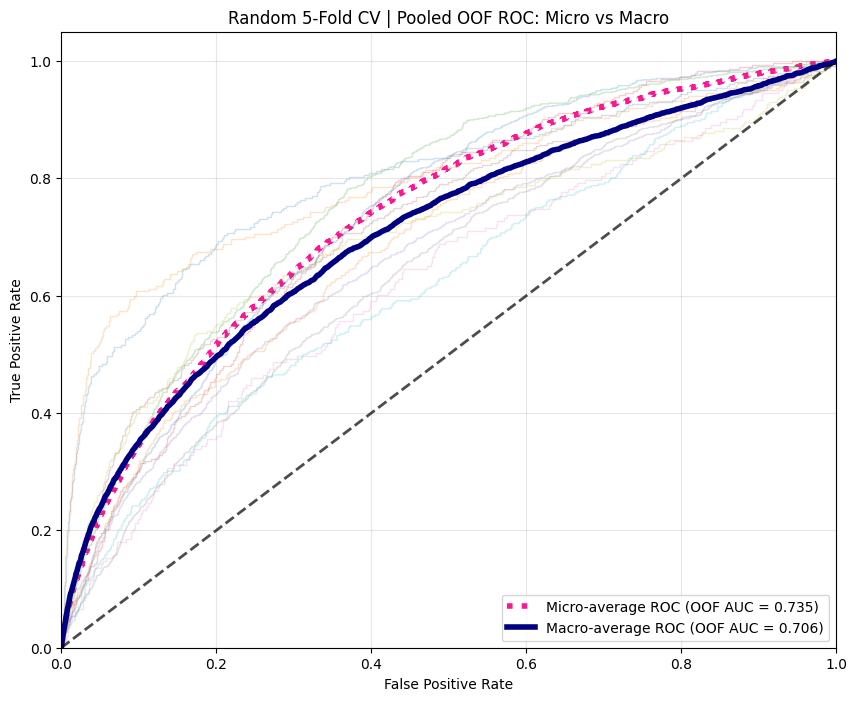

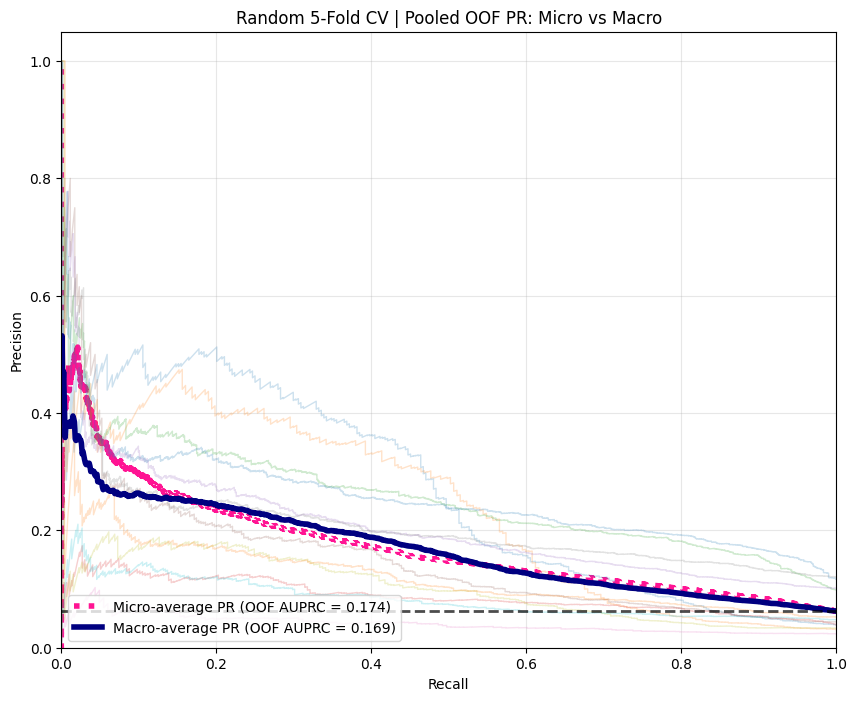

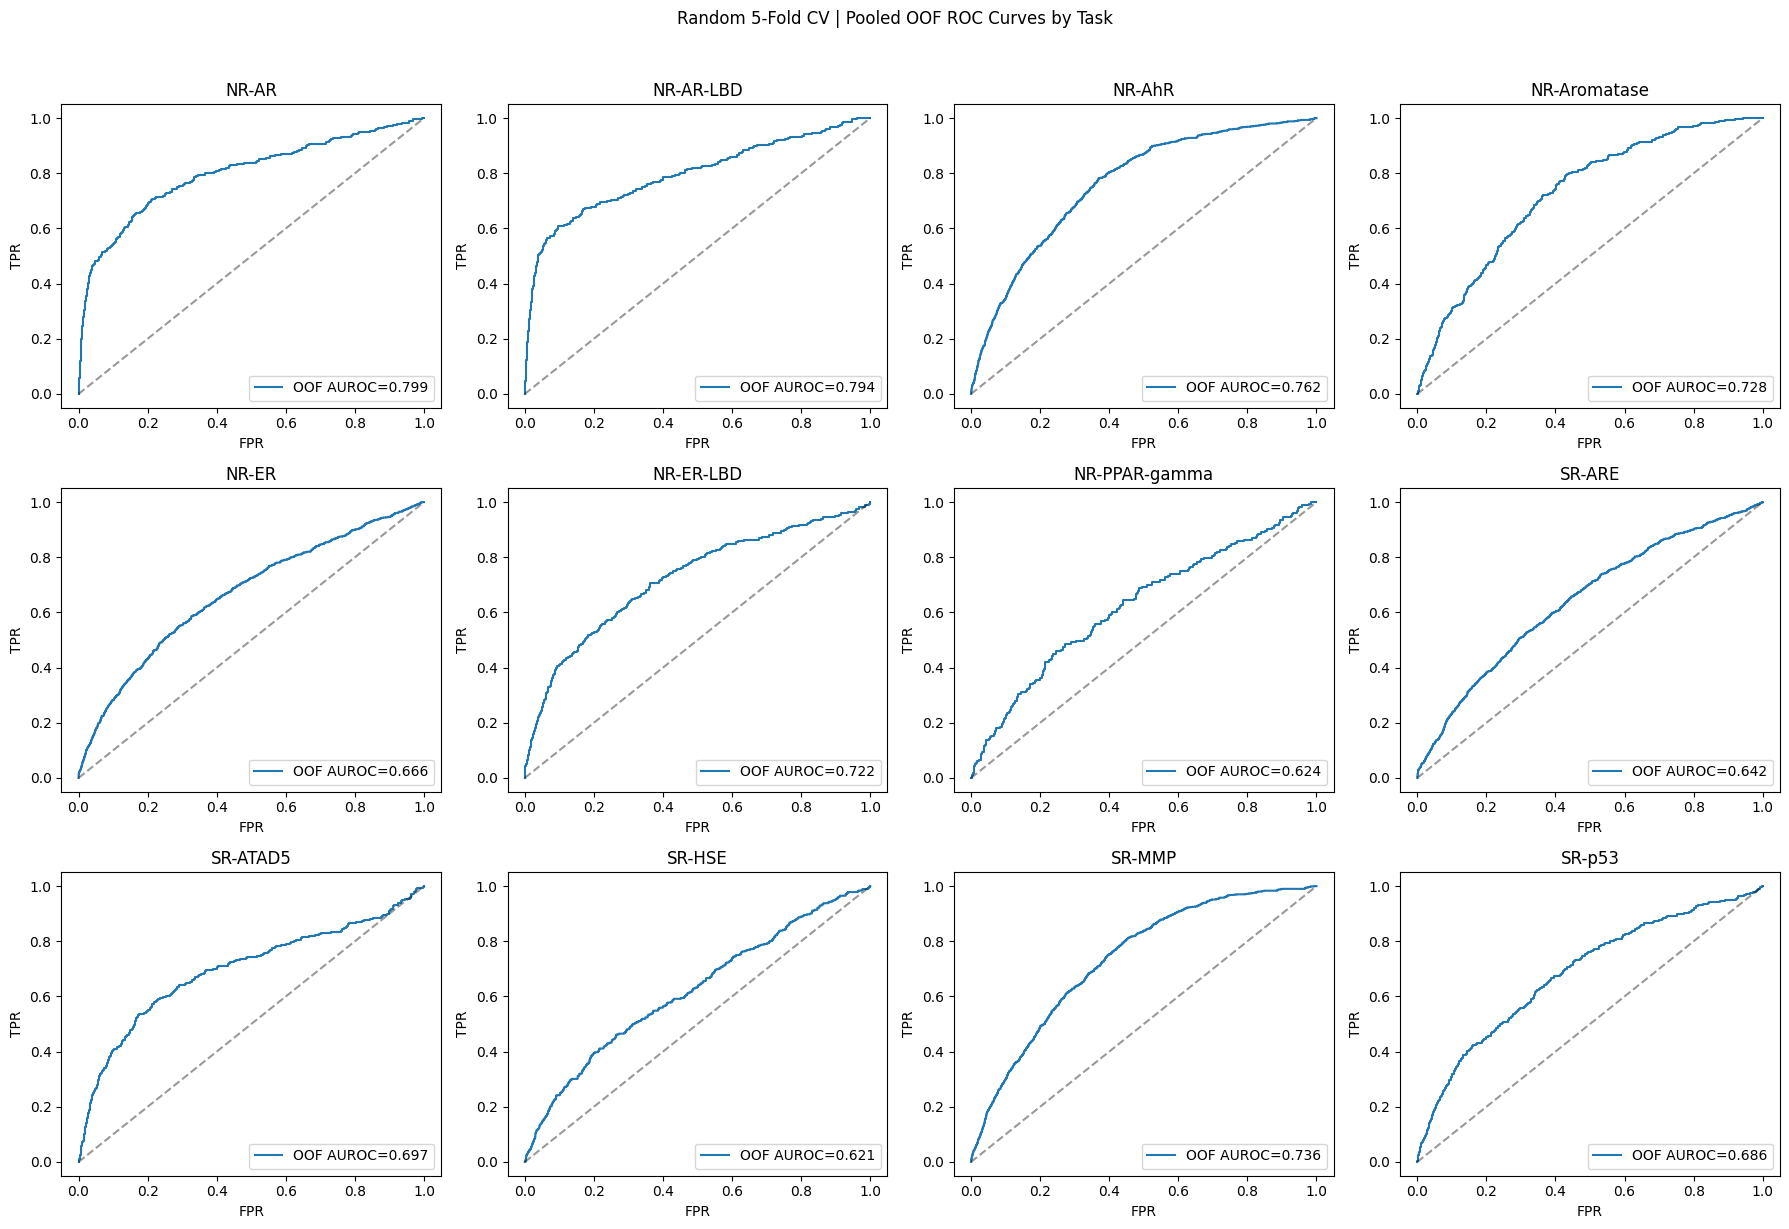

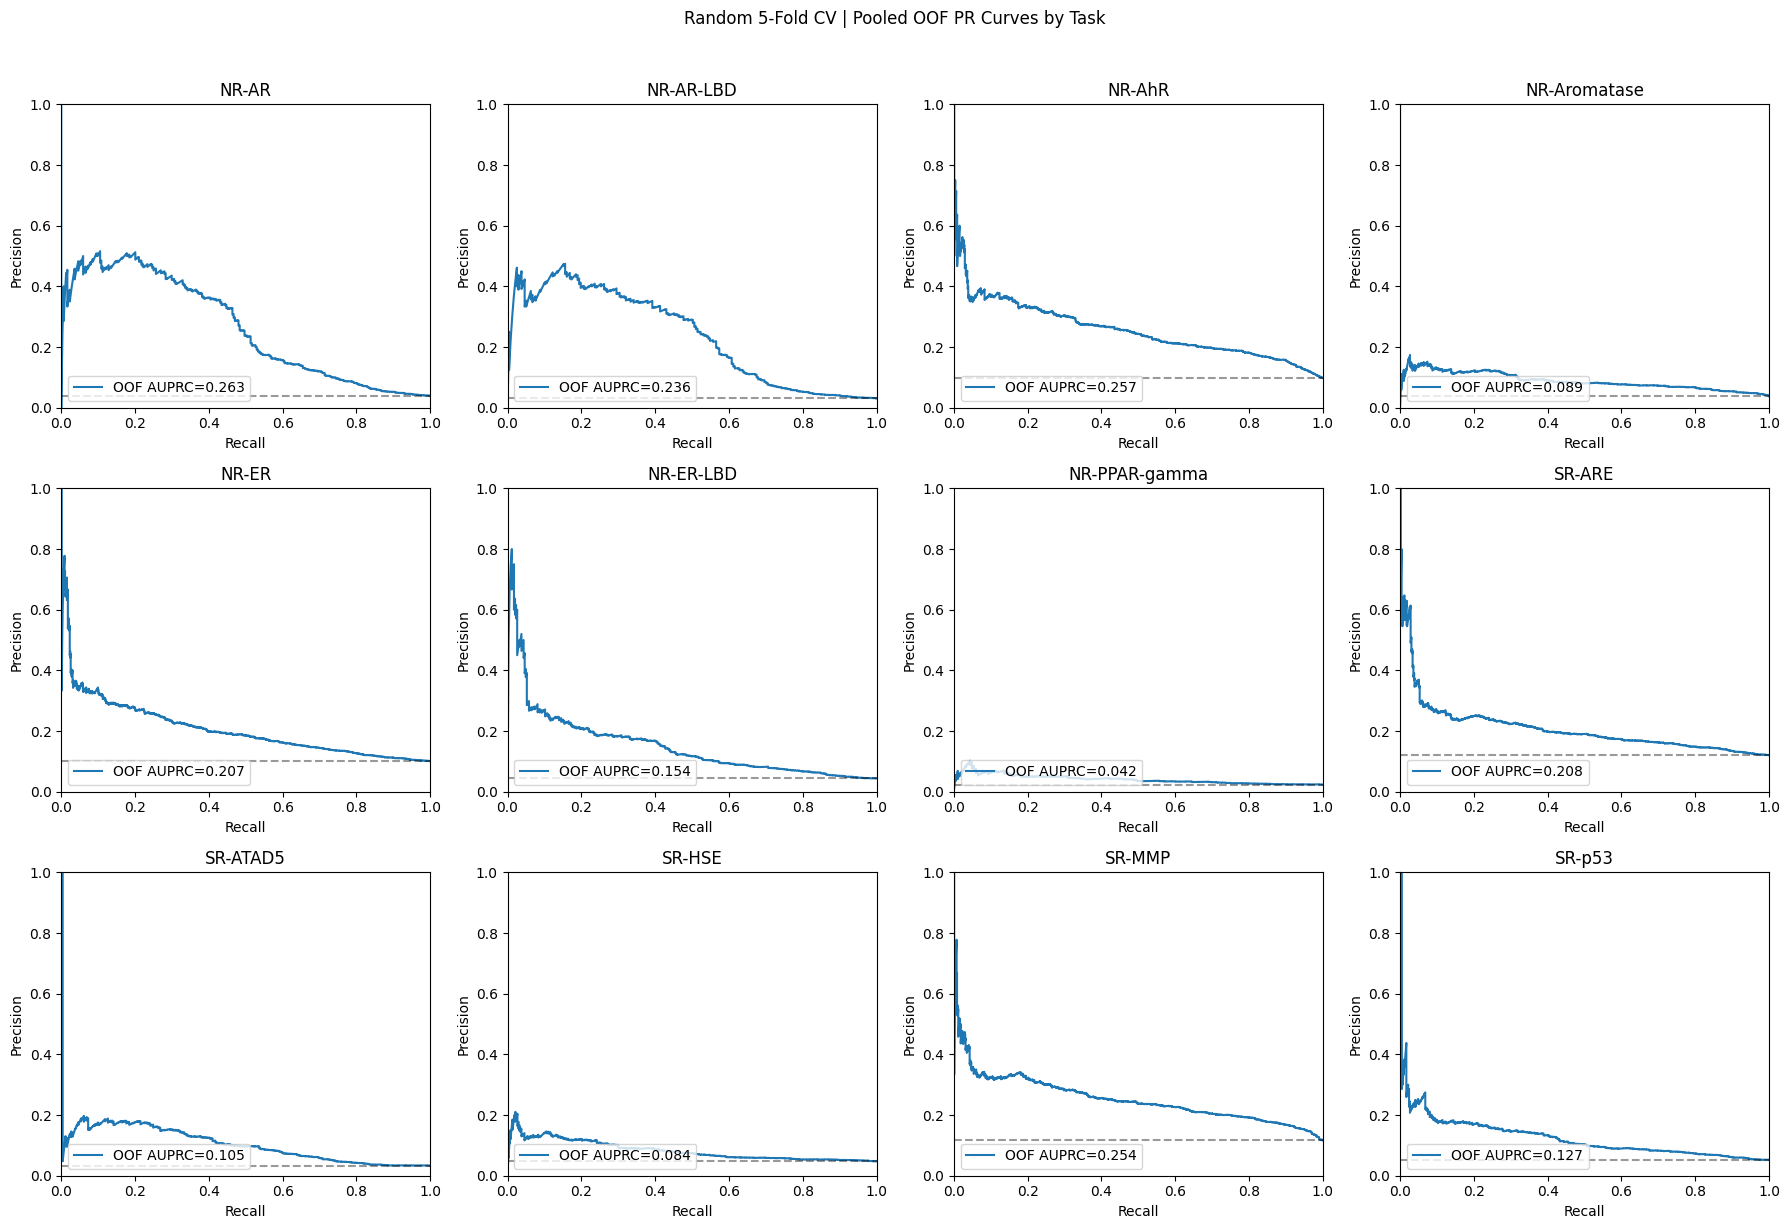


===== Multilabel Iterative Stratified 5-Fold CV =====
Fixed post-training recipe:
{'phase1_checkpoint_path': 'artifacts/end_to_end_checkpoints/e2evae_full_seqconv_ce_phase1_best.pt', 'posttraining_pipeline': 'stage_a_head_warmup_then_stage_b_full_unfreeze', 'warmup_epochs': 15, 'phase2_epochs': 80, 'warmup_lr': 0.0001, 'head_lr': 5e-05, 'base_lr': 1e-07, 'weight_decay': 0.01, 'phase2_pred_weight': 1.0, 'phase2_recon_weight': 0.0, 'kl_anneal_epochs': 10, 'min_epochs': 50, 'patience': 12, 'training_in_notebook': True}

Reporting convention:
- scalar metrics: mean/std across outer folds
- plots: pooled out-of-fold predictions from the outer held-out folds

Fold balance diagnostics:


,fold,n_train,n_inner_val,n_holdout,train_any_positive_rate,inner_val_any_positive_rate,holdout_any_positive_rate,train_mean_task_positive_rate,inner_val_mean_task_positive_rate,holdout_mean_task_positive_rate
0,1,5533,684,1555,0.371046,0.333333,0.359486,0.062142,0.062865,0.062219
1,2,5536,684,1552,0.370123,0.346491,0.356959,0.062018,0.063353,0.062446
2,3,5533,684,1555,0.366890,0.349415,0.367203,0.062172,0.062744,0.062165
3,4,5533,684,1555,0.365263,0.346491,0.374277,0.062187,0.062622,0.062165
4,5,5533,684,1555,0.365805,0.353801,0.369132,0.062097,0.063475,0.062111


Fold-level held-out metrics:


,fold,n_train,n_inner_val,n_holdout,best_epoch,best_inner_val_macro_auprc,best_inner_val_macro_auroc,macro_auroc,macro_auprc,micro_auroc,micro_auprc
0,1,5533,684,1555,106,0.192147,0.701184,0.717576,0.169307,0.739840,0.165879
1,2,5536,684,1552,106,0.156434,0.672776,0.733416,0.187139,0.744831,0.180760
2,3,5533,684,1555,106,0.179365,0.726175,0.701918,0.191229,0.732175,0.184195
3,4,5533,684,1555,106,0.214714,0.709199,0.703414,0.182502,0.732031,0.178240
4,5,5533,684,1555,107,0.165688,0.686297,0.693062,0.153366,0.719234,0.152029


Reportable CV summary (mean/std across folds) + pooled OOF reference:


,metric,cv_mean,cv_std,pooled_oof
0,macro_auroc,0.709877,0.015821,0.708558
1,macro_auprc,0.176709,0.015434,0.167270
2,micro_auroc,0.733622,0.009695,0.733425
3,micro_auprc,0.172221,0.013233,0.171231


Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):


,task,n_total,positive_rate,OOF_AUROC,OOF_AUPRC,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Accuracy_mean,Accuracy_std,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std
0,NR-AR-LBD,7772,0.030494,0.794973,0.230927,0.795908,0.056940,0.246227,0.076699,0.770334,0.015611,0.152615,0.017457,0.086014,0.009776,0.679344,0.098952
1,NR-AR,7772,0.039115,0.794645,0.264085,0.794996,0.039060,0.272611,0.058187,0.740347,0.014235,0.179542,0.009199,0.102466,0.005057,0.726995,0.063985
2,NR-AhR,7772,0.098688,0.759665,0.253814,0.760009,0.011567,0.261007,0.018407,0.520323,0.009777,0.265277,0.005397,0.156269,0.003303,0.877447,0.023274
3,SR-MMP,7772,0.116701,0.737728,0.258486,0.738539,0.013018,0.263557,0.010439,0.499489,0.006055,0.289352,0.006421,0.173412,0.003805,0.873189,0.023209
4,NR-ER-LBD,7772,0.044261,0.724539,0.148423,0.725373,0.016609,0.166500,0.039942,0.529083,0.021425,0.128613,0.008409,0.070061,0.004788,0.784193,0.033284
5,NR-Aromatase,7772,0.038085,0.724250,0.087564,0.726412,0.022486,0.095396,0.020332,0.520198,0.015539,0.112297,0.003934,0.060407,0.002068,0.797119,0.043968
6,SR-ATAD5,7772,0.033582,0.701307,0.098697,0.701980,0.031487,0.106543,0.016848,0.511439,0.025578,0.094086,0.003068,0.050176,0.001732,0.754717,0.025807
7,SR-p53,7772,0.052625,0.689228,0.122291,0.689547,0.023588,0.128787,0.014674,0.458311,0.007379,0.132644,0.007009,0.072424,0.003783,0.787383,0.048799
8,NR-ER,7772,0.100875,0.667328,0.206836,0.667832,0.031777,0.217243,0.037544,0.396291,0.010649,0.215314,0.004968,0.123903,0.002578,0.821370,0.033277
9,SR-ARE,7772,0.120818,0.646209,0.209295,0.647118,0.017199,0.213716,0.013520,0.323979,0.022037,0.240079,0.004553,0.138923,0.002619,0.883923,0.034741


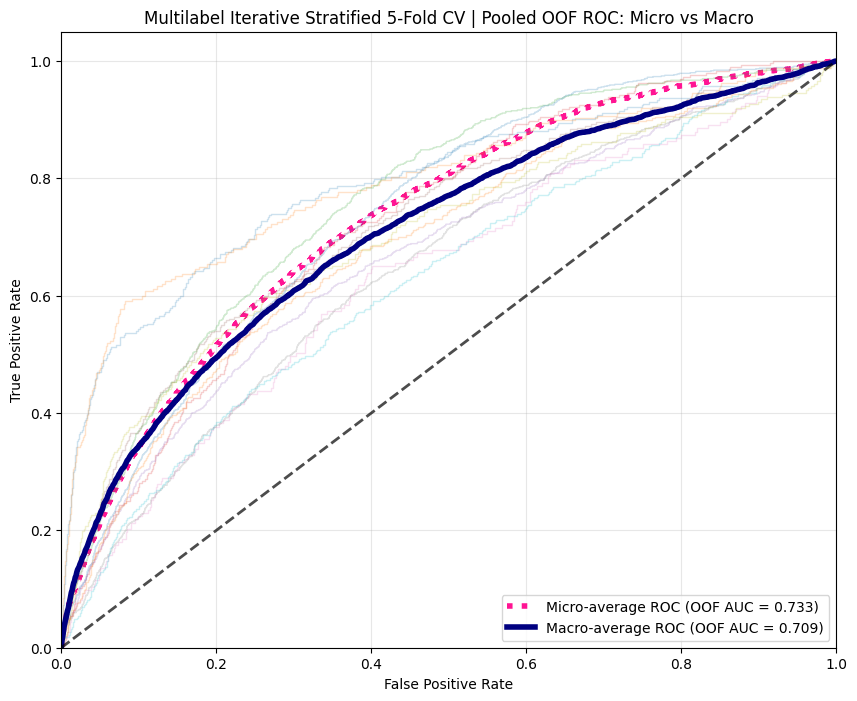

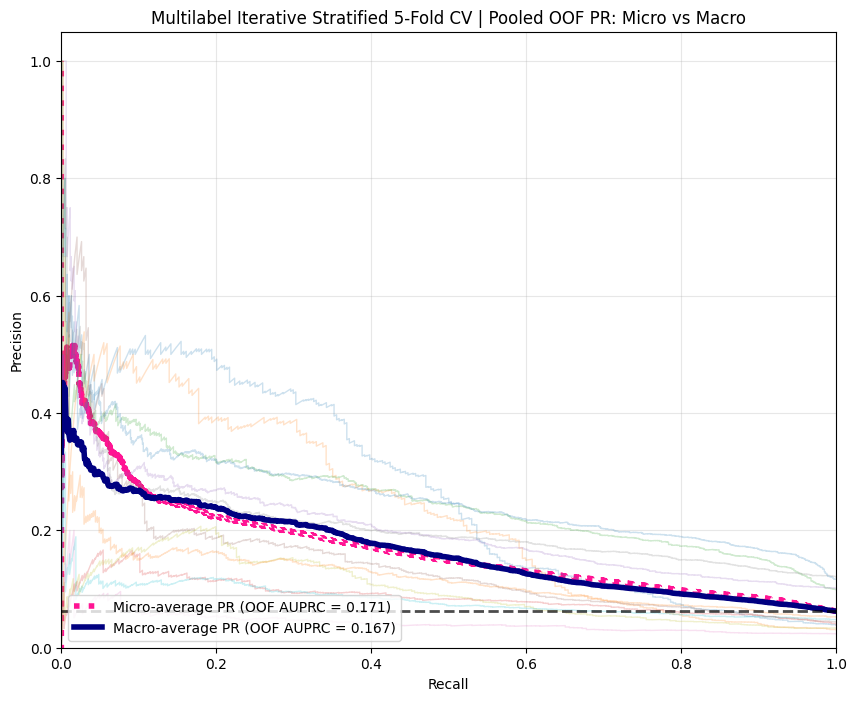

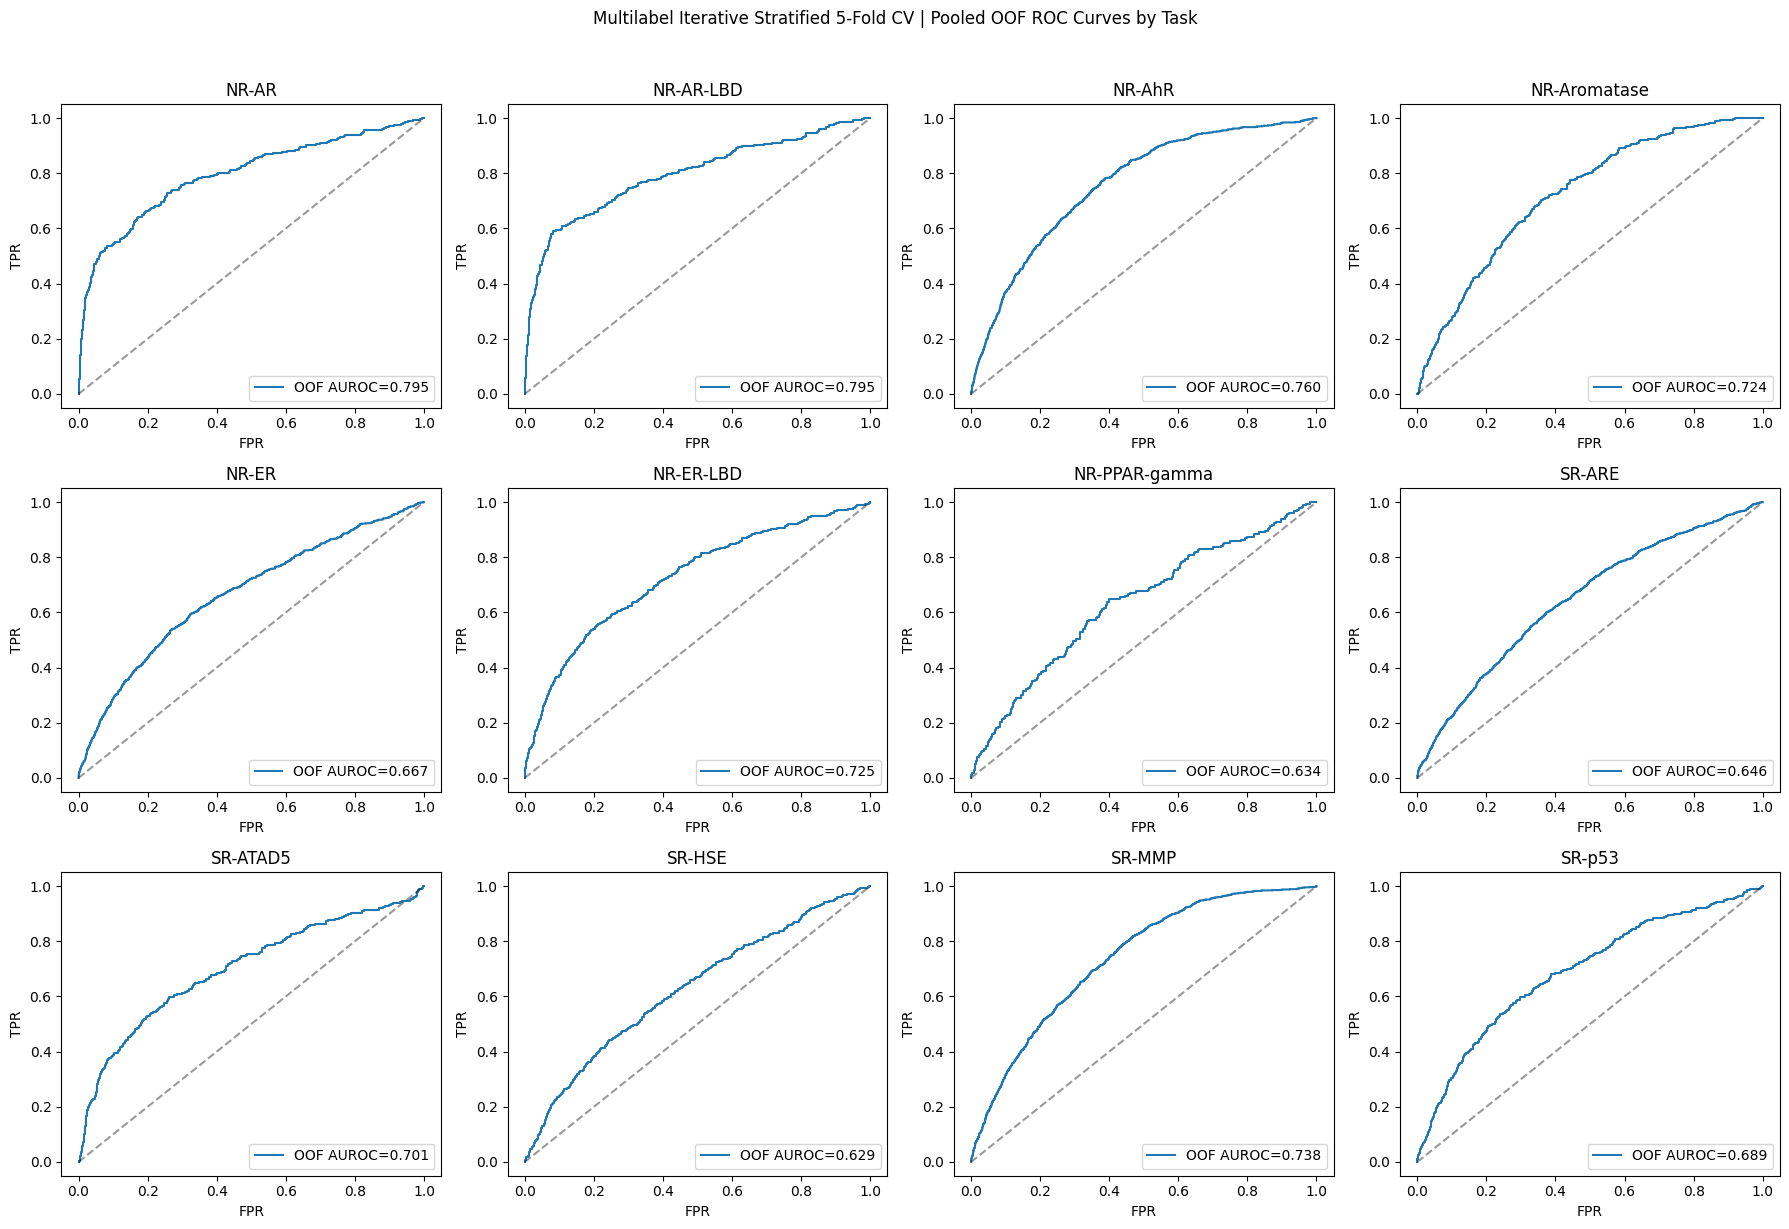

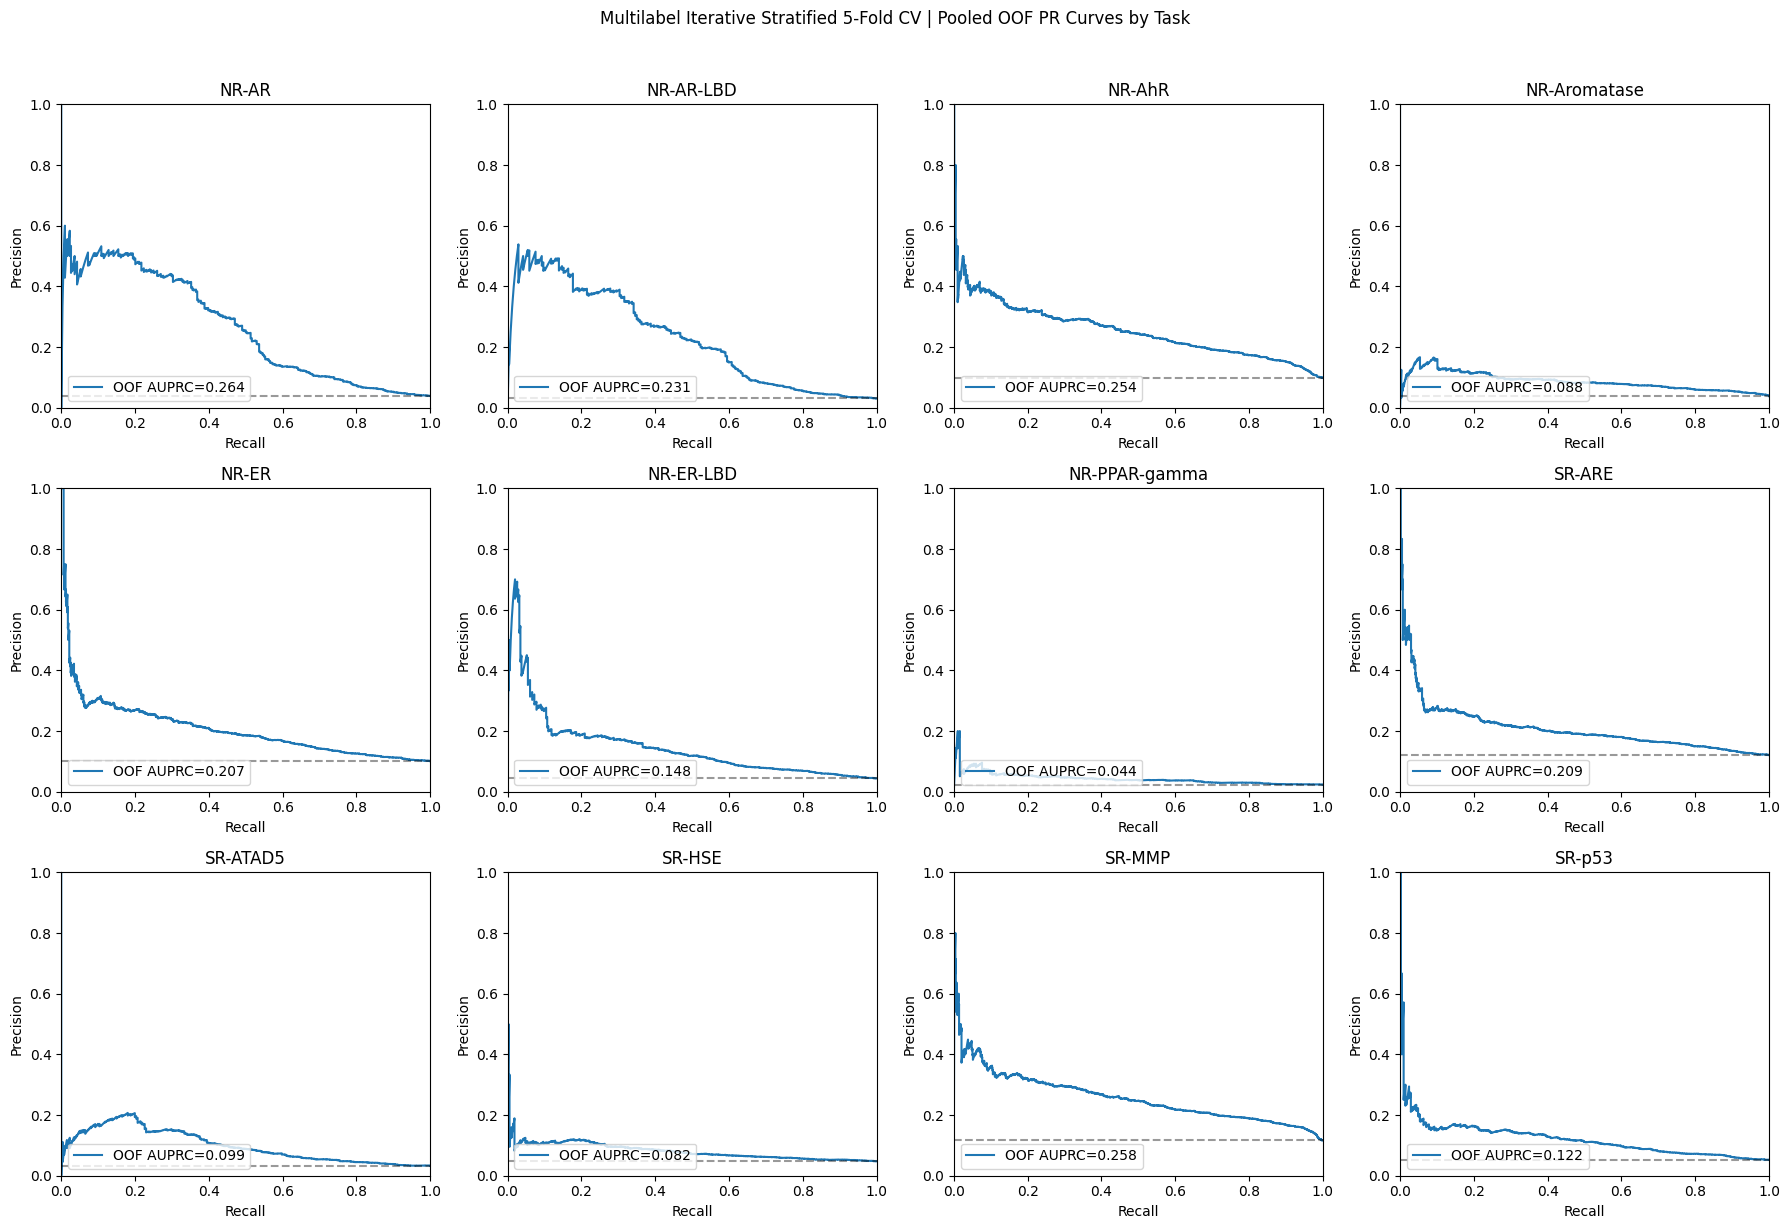

In [8]:
for strategy in STRATEGY_ORDER:
    if strategy not in experiment_results:
        continue

    result = experiment_results[strategy]

    print()
    print(f"===== {result['name']} =====")
    print('Fixed post-training recipe:')
    print(result['fixed_params'])
    print()
    print('Reporting convention:')
    print('- scalar metrics: mean/std across outer folds')
    print('- plots: pooled out-of-fold predictions from the outer held-out folds')

    print()
    print('Fold balance diagnostics:')
    display(result['fold_balance_df'])

    print('Fold-level held-out metrics:')
    display(result['fold_summary_df'])

    print('Reportable CV summary (mean/std across folds) + pooled OOF reference:')
    display(result['global_report_df'])

    print('Per-task summary (fold mean/std plus pooled OOF AUROC/AUPRC):')
    display(result['task_summary_df'])

    plot_micro_macro_roc(result)
    plot_micro_macro_pr(result)
    plot_per_task_roc_grid(result, TOX21_TASKS)
    plot_per_task_pr_grid(result, TOX21_TASKS)


## 9. Final Comparison Snapshot

In [9]:
final_summary = comparison_df.copy()
final_summary

,strategy,strategy_label,mean_best_epoch,macro_auroc_cv_mean,macro_auroc_cv_std,macro_auroc_pooled_oof,macro_auprc_cv_mean,macro_auprc_cv_std,macro_auprc_pooled_oof,micro_auroc_cv_mean,micro_auroc_cv_std,micro_auroc_pooled_oof,micro_auprc_cv_mean,micro_auprc_cv_std,micro_auprc_pooled_oof
0,random,Random 5-Fold CV,106.0,0.707904,0.008995,0.706499,0.178535,0.014173,0.168905,0.734694,0.005001,0.734540,0.175735,0.013606,0.173790
1,multilabel_iterstrat,Multilabel Iterative Stratified 5-Fold CV,106.2,0.709877,0.015821,0.708558,0.176709,0.015434,0.167270,0.733622,0.009695,0.733425,0.172221,0.013233,0.171231
